In [13]:
from reinvent_lm.generation import MoleculeGenerator
from reinvent_lm.filters import StructureFilter

molecule_generator = MoleculeGenerator(tokenizer_path="checkpoints/reinvent_property_guided/tokenizer.json", config_path="configs/train_reinvent.yaml", checkpoint_path="checkpoints/reinvent_property_guided/checkpoint_epoch_40.pt", device="cuda")

使用設備: cuda
載入配置檔案: configs/train_reinvent.yaml
載入 tokenizer: checkpoints/reinvent_property_guided/tokenizer.json
Tokenizer 已從 checkpoints/reinvent_property_guided/tokenizer.json 加載
詞彙表大小: 26
建立模型...
載入模型權重: checkpoints/reinvent_property_guided/checkpoint_epoch_40.pt
✓ MoleculeGenerator 初始化完成 (從檢查點載入)!



（73 個無效分子已略過，不會顯示在圖片中）


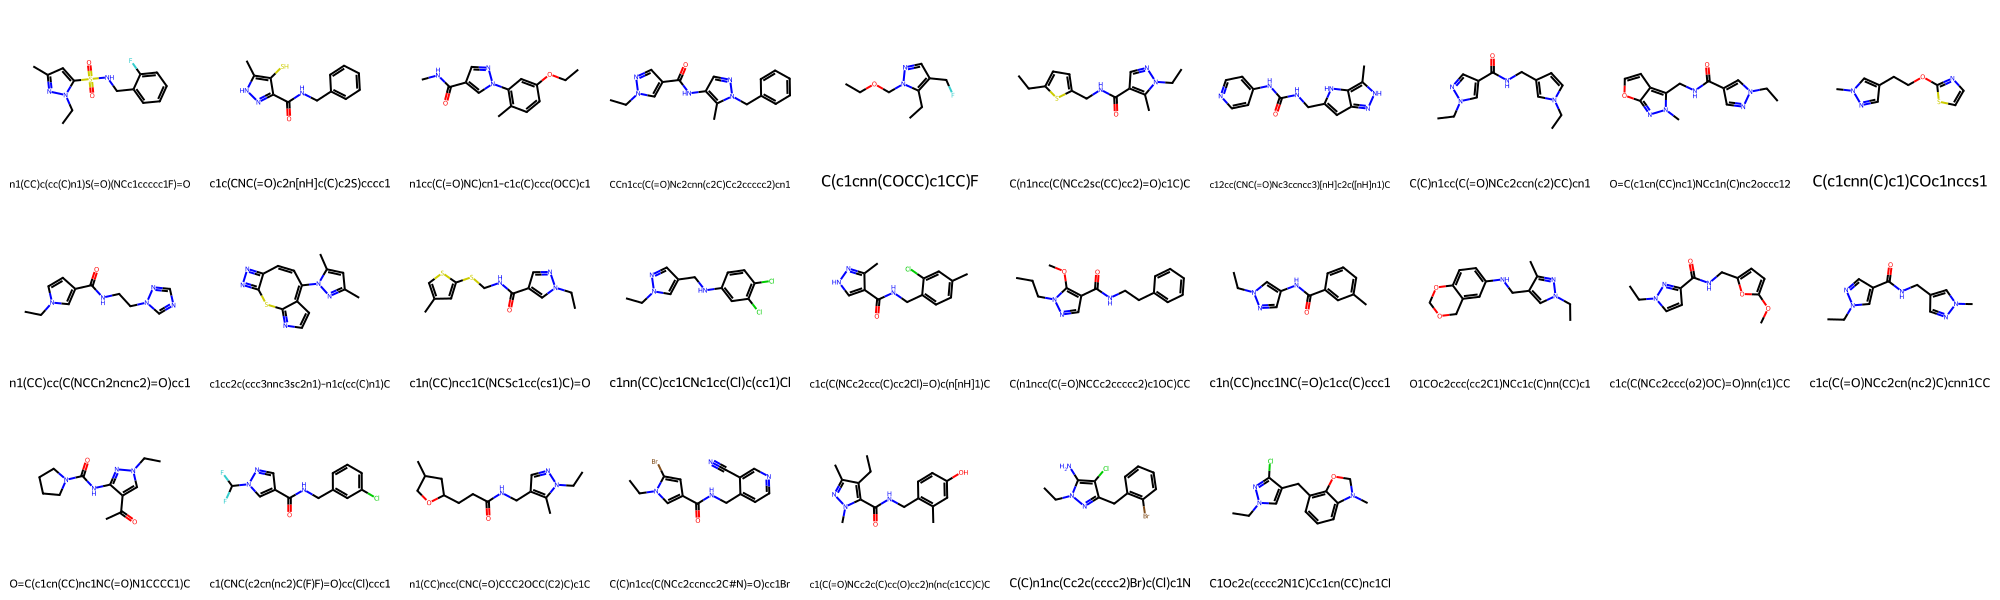

['O1c2c(ccc(Cl)c2)ClCCc1=O)-n1[nH]ccc1',
 'c1(C(NCc2ccccc2)n2cc(Cl)cn2)=O)c(Cl)cccc1',
 'n1(CC)c(cc(C)n1)S(=O)(NCc1ccccc1F)=O',
 'O=C(NCc1c(Cc)[nH]nc1Oc1ccccc1)C',
 'c12ccc(CCNC(NC3CC3)=O)n1=C(Oc2cc)CC',
 'O1COc2c(CCCn3nc(C)cc32)sc1',
 'n1n(CC)c(cc1C(NCSc1c(snn1)C)=O',
 'c12cc(CNC(c1n(ncc(c2Cl)C)C)=O)cc(C)sc1F',
 'c1c(CNC(=O)c2n[nH]c(C)c2S)cccc1',
 'c1nn(CC)cc1C(=O)Nc1c2OCCOSc2cc-1',
 'n1cc(C(=O)n2ccc(-)n2)oOc2c1ccc(OC)c2',
 'c1c2c(cc(CNCn3c2ccc(Cl)c3)nc2)ncc1',
 'O=C(c1cnc2cc(C)c3n(C(F)F)s[nH][nH]3)c231',
 'n1cc(C(=O)NC)cn1-c1c(C)ccc(OCC)c1',
 'c12cc(CCn3ccc(C)n3)cc2onc1O',
 'O=C(NCc1ccc2c(ccc2F)n1)C',
 'CCn1cc(C(=O)Nc2cnn(c2C)Cc2ccccc2)cn1',
 'O1COc2c1cc(-c1c(NS(=O)(N3C))=O)[nH](nn1)CO)noCl',
 'n1cc(C(N(Cc2cn[nH]c2Cl)C)=O)nc(c1)-n(c(C)cc1)CC',
 'C(c1cnn(COCC)c1CC)F',
 'CCn1cc(C(NCc2nc3cc(nn3c(N2)CC)c2N)=O)cc1',
 'C(NCc1cc2c(cc1)ccCC(=O)N2CC)c2C#N',
 'C(n1cc(C(OC)=N)nc1)O=Cc1ccc(Cl)cc1C',
 'C(NCc1cc2c(cc1OC)cccc2)(c1cnnc1)=O',
 'C1Oc2c(ccc(CNc3nn2c3nc(C',
 'C(n1ncc(C(NCc2sc(CC)cc2)=O)

In [14]:
molecule_generator.sample_from_prefix("CCn1cc(C(=O)NCc2ccc3c(c2)OCO3)cn1", 100, temperature=2., truncate_fraction_range=(0.2,0.4), display_molecules=True, seed=1)

In [21]:
from reinvent_lm.properties import PropertyInferenceAPI
from reinvent_lm.pareto import PropertySpec

property_specs = {"ClogP": PropertySpec(goal="maximize"), "SAScore": PropertySpec(goal="range", low=1.5, high=2.5), "MolWt": PropertySpec(goal="range", low=380, high=470)}

inference_api = PropertyInferenceAPI()
results = molecule_generator.generate_analogs(['Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1'], 10000, temperature=2., display_molecules=False, seed=1, inference_api=inference_api, target_spec=property_specs)

In [24]:
results[results["front_rank"]==2]

,smiles,seed,ClogP,SAScore,MolWt,front_rank
3,c1(C)cc(NC(Nc2c(Cl)c(Cl)ccc2Cl)=O)n(C)c1-c1ccccc1,Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1,6.60472,2.419089,408.716,2
4,Clc1ccc(NC(=O)C(n2c(CC)ccc2-c2ccc(Cl)cc2)C)cc1Cl,Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1,6.87740,2.721037,421.755,2


（5 個無效分子已略過，不會顯示在圖片中）


/home/lungyi/miniconda3/envs/transformervae/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


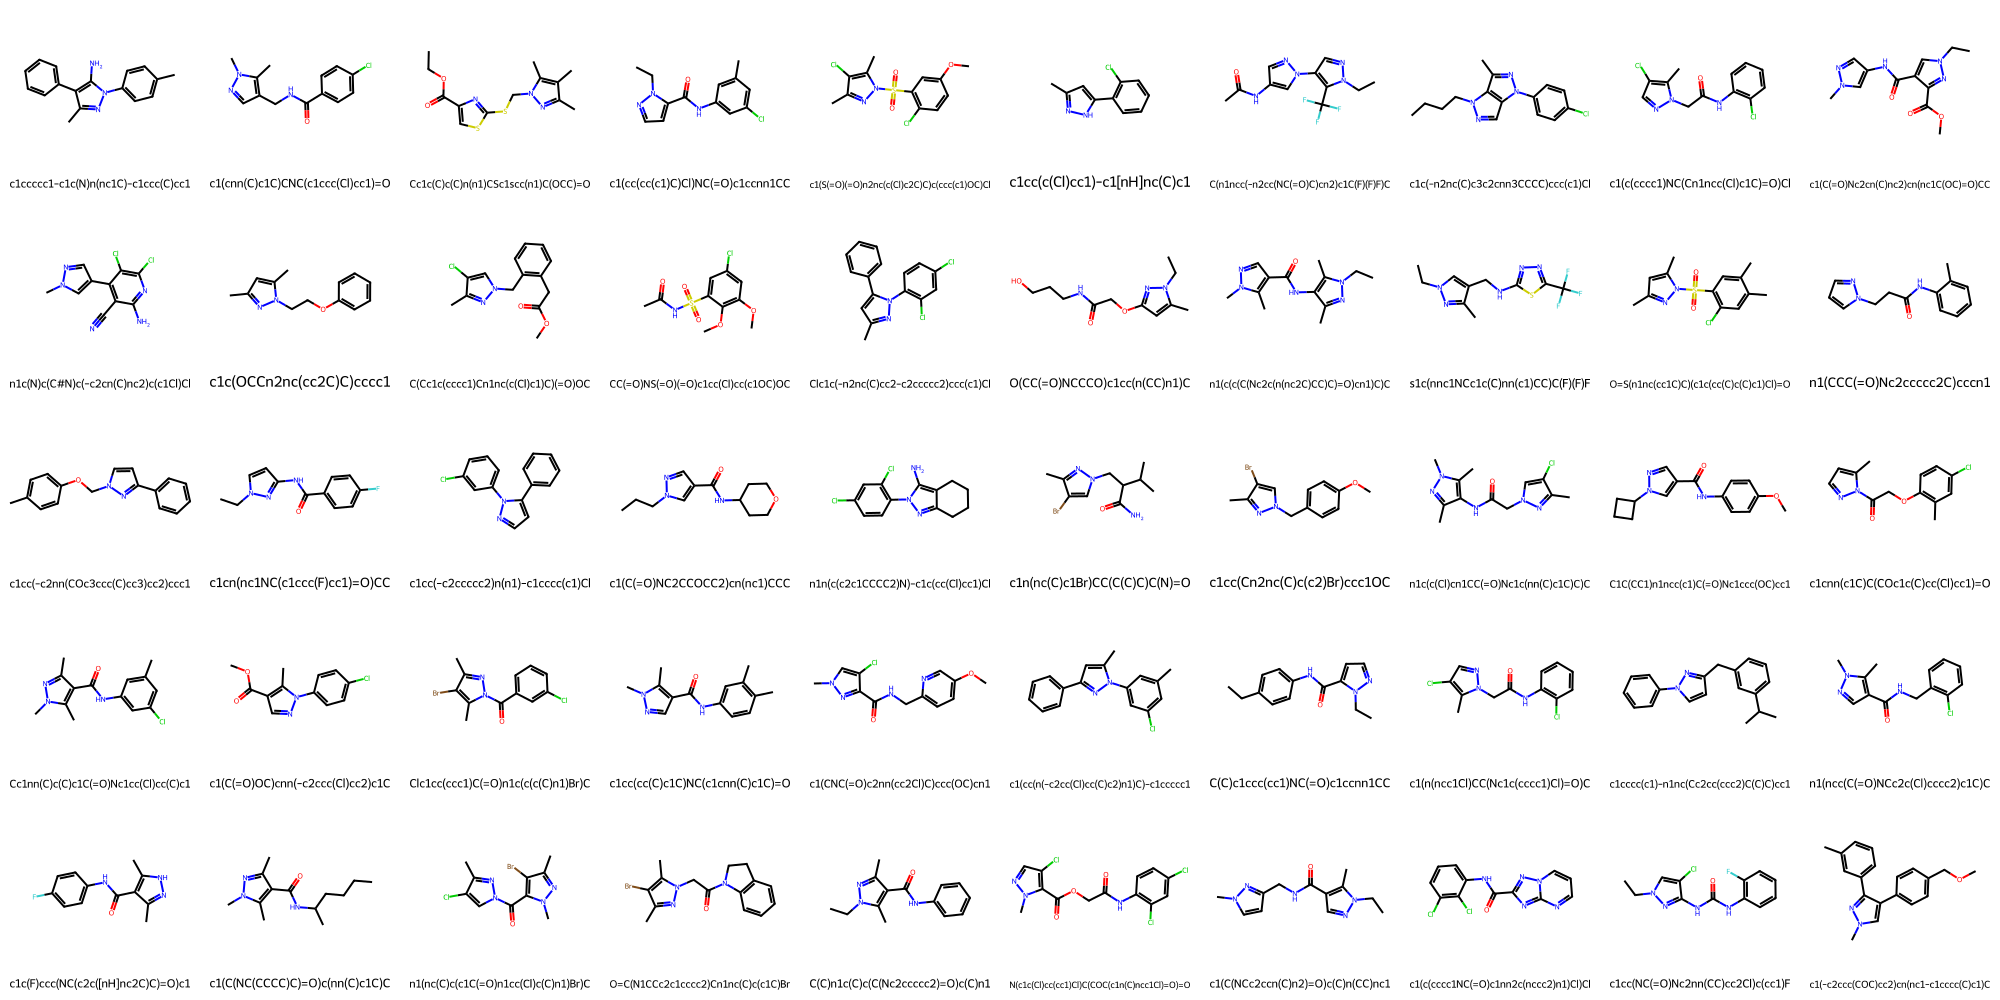

In [25]:
results = molecule_generator.sample(1000, display_molecules=False)

In [19]:
from reinvent_lm.tokenizer import randomize_smiles

randomize_smiles("CC(O)CCNC(OCCBr)CCl", seed=5)

'OC(CCNC(CCl)OCCBr)C'